# Environment

- by timepoint...
  - celltype percentage/enrichment per neighborhood -- how to compare?
  - celltype DEGs
  - neighborhood DEGs
  - GO enrichment per celltype
- what's the follow-up?
  - target gene or mouse model?

In [ ]:
# base
import os
import sys
import gc
import pickle
from pathlib import Path
import warnings
import logging

sys.path.insert(0, '../../..')
logging.basicConfig(level="WARNING")
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

# data manipulation
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.simplefilter("ignore", pd.errors.DtypeWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.WARNING)

# single cell
import anndata as ad
import scanpy as sc
import squidpy as sq
import liana as li

# custom
from single_cell.R import *
from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from spatial_seq.plot import *
from utils import *

# R
import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter

%load_ext rpy2.ipython
%matplotlib inline

# analysis & device specific
CORES = 20
DATADIR = Path("../../../../data") / "processed" / "external"
REFDIR = Path("../../../../references") / "Pailin_references"
converter = get_converter()
mpl.rcdefaults()

def AddPailinLabels(ax, adata, fontsize=10):
    for i in range(3):
        ax.text(
            (i + 0.5) / 3,
            0.97,
            adata.obs["batch"].cat.categories.to_list()[i],
            transform=ax.transAxes,
            ha="center",
            fontsize=fontsize / 2,
        )
    for i in range(3):
        ax.text(
            0.04,
            1 - (i + 0.5) / 3,
            adata.obs["timepoint"].cat.categories.to_list()[i],
            transform=ax.transAxes,
            va="center",
            ha="right",
            rotation=90,
            fontsize=fontsize,
        )


gc.collect()

/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/phenograph/cluster.py:13: DeprecationWarning: Please import `spmatrix` from the `scipy.sparse` namespace; the `scipy.sparse.base` namespace is deprecated and will be removed in SciPy 2.0.0.


100926

# Load Data

In [ ]:
adata = sc.read_h5ad(DATADIR / "processed" / "spatial" / "external" / "adata.h5ad")
adata.obs = adata.obs.drop(columns="ident")
sc.pp.filter_genes(adata, min_cells=10)
adata.layers["counts"] = adata.X.copy()
sc.pp.log1p(adata, layer="logcounts")
adata

In [ ]:
from pandas.api.types import CategoricalDtype

# fix spatial
adata.obs["x"], adata.obs["y"] = np.hsplit(adata.obsm["SPATIAL"], 2)
adata.obs = adata.obs.rename(columns={"orig.ident": "batch"})

slide_batch = "batch"

samples = adata.obs[slide_batch].unique()
ref = samples[0]
for n in np.arange(1, len(samples)):
    ref = samples[n - 1]
    samp = samples[n]
    ref_adata = adata[adata.obs[slide_batch] == ref].copy()
    new_adata = adata[adata.obs[slide_batch] == samp].copy()

    adata.obs["x"].loc[new_adata.obs_names], adata.obs["y"].loc[new_adata.obs_names] = (
        concat_spatial(
            new_adata.obs["x"],
            new_adata.obs["y"],
            ref_adata.obs["x"],
            ref_adata.obs["y"],
            offset_x=0.3,
        )
    )

adata.obs["y"] = -adata.obs["y"] + np.max(adata.obs["y"])
adata.obsm["SPATIAL"] = adata.obs[["x", "y"]].to_numpy()

# add celltypes
celltype_mapping = {
    0: "Inhibitory neurons",
    1: "Excitatory neurons",
    2: "Astrocytes",
    3: "Oligodendrocytes",
    4: "Endothelial",
    5: "Oligodendrocytes",
    6: "Excitatory neurons",
    7: "Excitatory neurons",
    8: "Microglia",
    9: "Pericytes",
    10: "OPC",
    11: "Fibroblasts",
    12: "Airway neurons",
    13: "Astrocytes",
    14: "Neu ",
    15: "Neu Phox2b+",
    16: "Oligodendrocytes",
    17: "SERT neurons",
    18: "Ependymal (V4 lining)",
}
adata.obs["celltype"] = adata.obs["seurat_clusters"].astype(int).map(celltype_mapping)

# add timepoints
timepoints = pd.read_csv(
    DATADIR / "processed" / "spatial" / "external" / "cloupe_timepoints_barcodes.csv"
).set_index("Barcode")
adata.obs.loc[timepoints.index, "timepoint"] = list(timepoints.iloc[:, 0])
adata.obs["timepoint"] = adata.obs["timepoint"].replace({"nan": "no timepoint"})
order_obs(adata, "timepoint", ["pbs", "7dpi", "3wpi", "no timepoint"])

# other cleaning
adata.obs_names = adata.obs_names.astype("object")
adata.var_names = adata.var_names.astype("object")

adata

In [ ]:
adata = adata[adata.obs["timepoint"] != "no timepoint"]
adata.obs["sample"] = (
    adata.obs["batch"].astype(str) + ":" + adata.obs["timepoint"].astype(str)
).astype("category")

adata.var["mt"] = adata.var_names.str.startswith("mt-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)
sc.pp.calculate_qc_metrics(adata, inplace=True)

In [ ]:
# plot
f, ax = plt.subplots(4, 1, figsize=(20, 18), layout="constrained")
sc.pl.spatial(
    adata,
    basis="SPATIAL",
    color="batch",
    spot_size=100,
    ax=ax[0],
    show=False,
    palette=create_palette(3),
)
sc.pl.spatial(
    adata,
    basis="SPATIAL",
    color="timepoint",
    spot_size=100,
    ax=ax[1],
    show=False,
    palette=create_palette(3) + ["#000000"],
)
sc.pl.spatial(
    adata,
    basis="SPATIAL",
    color="sample",
    spot_size=100,
    ax=ax[2],
    show=False,
    palette=create_palette(len(adata.obs["sample"].unique())),
)
sc.pl.spatial(
    adata, basis="SPATIAL", color="celltype", spot_size=100, ax=ax[3], show=False
)

In [ ]:
f, ax = plt.subplots(2, 1, figsize=(20, 12), layout="constrained")
sc.pl.spatial(
    adata,
    basis="SPATIAL",
    color="Chat",
    spot_size=100,
    layer="logcounts",
    cmap="Blues",
    ax=ax[0],
    show=False,
)
sc.pl.spatial(
    adata,
    basis="SPATIAL",
    color="Phox2b",
    spot_size=100,
    layer="logcounts",
    cmap="Blues",
    ax=ax[1],
    show=False,
)

In [ ]:
adata.write(DATADIR / "processed" / "external" / "initial_clean.h5ad")

# Add neighborhoods

In [ ]:
adata = sc.read_h5ad(DATADIR / "processed" / "external" / "initial_clean.h5ad")
sq.gr.spatial_neighbors(adata, spatial_key="spatial")
gc.collect()

In [ ]:
# Add Banksy
filename = DATADIR / "processed" / "external" / "banksy" / "banksy_results.pkl"
batch_key = "batch"

with open(filename, "rb") as file:
    banksy_dict, results_df, max_num_labels = pickle.load(file)

results_df.iloc[:, results_df.columns != "adata"]
for l in results_df["lambda_param"].unique():
    result = results_df[results_df["lambda_param"] == l].adata[0]
    for col in result.obs:
        if "label" in col:
            adata.obs["BANKSY_" + col] = result.obs[col]

In [ ]:
# Add Cellcharter
import cellcharter as cc

savedir = DATADIR / "processed" / "external" / "cellcharter"
with open(savedir / "autok.pkl", "rb") as file:
    autok = pickle.load(file)
adata_cc = sc.read_h5ad(savedir / "cellcharter.h5ad")
cc.pl.autok_stability(autok)

ks = [9]
for k in ks:
    adata.obs[f"cellcharter_k{k}"] = autok.predict(
        adata_cc, use_rep="X_cellcharter", k=k
    )
adata.obsm["X_cellcharter"] = adata_cc.obsm["X_cellcharter"].copy()
adata.obsm["X_scVI"] = adata_cc.obsm["X_scVI"].copy()

In [ ]:
# fix spatial again
def spatial_batchMove(adata, batch, x_offset_perc, y_offset_perc, old_key, new_key):
    adata.obs["x"], adata.obs["y"] = np.hsplit(adata.obsm[old_key], 2)

    x_range = np.mean(
        [(df["x"].max() - df["x"].min()) for _, df in adata.obs.groupby(batch)]
    )
    for i, t in enumerate(adata.obs[batch].unique()):
        adata.obs.loc[adata.obs[batch] == t, "x"] += x_offset_perc * x_range * i + 1

    y_range = np.mean(
        [(df["y"].max() - df["y"].min()) for _, df in adata.obs.groupby(batch)]
    )
    for i, t in enumerate(adata.obs[batch].unique()):
        adata.obs.loc[adata.obs[batch] == t, "y"] += y_offset_perc * y_range * i + 1

    adata.obsm[new_key] = adata.obs[["x", "y"]].to_numpy()


spatial_batchMove(adata, "timepoint", 0.08, 2, "SPATIAL", "spatial")
spatial_batchMove(adata, "timepoint", 0, -1, "spatial", "spatial")
spatial_batchMove(adata, "batch", -1, 0, "spatial", "spatial")

In [ ]:
color = "sample"
sc.pl.spatial(
    adata,
    basis="spatial",
    color=color,
    spot_size=50,
    palette=create_palette(len(adata.obs[color].unique())),
)
sc.pl.spatial(
    adata,
    basis="SPATIAL",
    color=color,
    spot_size=50,
    palette=create_palette(len(adata.obs[color].unique())),
)

In [ ]:
sq.gr.spatial_neighbors(adata, spatial_key="spatial")
sq.gr.spatial_autocorr(adata, mode="moran", genes=adata.var_names)
sq.gr.spatial_autocorr(adata, mode="geary", genes=adata.var_names)

In [ ]:
adata.write(DATADIR / "processed" / "external" / "neigborhoods_added.h5ad")

# Compare neighborhood assingments

In [ ]:
adata = sc.read_h5ad(DATADIR / "processed" / "external" / "neigborhoods_added.h5ad")
sq.gr.spatial_neighbors(adata, spatial_key="spatial")
gc.collect()

In [ ]:
import plotly.graph_objects as go
from collections import Counter

cluster_labels1, cluster_labels2 = np.hsplit(
    adata.obs[["cellcharter_k8", "cellcharter_k9"]].values, 2
)
cluster_labels1 = cluster_labels1.flatten()
cluster_labels2 = cluster_labels2.flatten()
N = adata.shape[0]


def cluster_sankey(cluster_labels1, cluster_labels2, name1="", name2="", min_flow=50):
    flow_counts = Counter(zip(cluster_labels1, cluster_labels2))
    flow_counts = {k: v for k, v in flow_counts.items() if v >= min_flow}

    clusters1 = sorted(set(cluster_labels1))
    clusters2 = sorted(set(cluster_labels2))

    source = [clusters1.index(c1) for c1, c2 in flow_counts]
    target = [len(clusters1) + clusters2.index(c2) for c1, c2 in flow_counts]
    value = list(flow_counts.values())

    counts1 = Counter(cluster_labels1)
    counts2 = Counter(cluster_labels2)
    labels = [f"{name1}{c} ({counts1[c]})" for c in clusters1] + [
        f"{name2}{c} ({counts2[c]})" for c in clusters2
    ]

    fig = go.Figure(
        go.Sankey(
            node=dict(label=labels, pad=15, thickness=20),
            link=dict(source=source, target=target, value=value),
        )
    )

    fig.update_layout(title="Cluster Assignment Comparison", font_size=12)
    fig.show()


cluster_sankey(cluster_labels1, cluster_labels2, "K8_", "K9_", N * 0.01)
cluster_sankey(adata.obs["celltype"], adata.obs["cellcharter_k8"])

In [ ]:
s1 = adata[adata.obs["sample"] == adata.obs["sample"].unique()[0]].copy()
sc.pl.spatial(
    s1, basis="spatial", color=["cellcharter_k8", "cellcharter_k9"], spot_size=50
)
adata.obs["temp"] = adata.obs["cellcharter_k8"].isin(["0", "3", "5"])
sc.pl.spatial(s1, basis="spatial", color=["temp"], spot_size=50, title="0/3/5 in K8")
adata.obs["temp"] = adata.obs["cellcharter_k9"].isin(["2", "0", "4", "7", "5"])
sc.pl.spatial(
    s1, basis="spatial", color=["temp"], spot_size=50, title="0/2/4/5/7 in K9"
)
# sc.pl.spatial(s1, basis='spatial', color=['Fos'], spot_size=50, title="0/2/4/5/7 in K9", layer="logcounts", cmap="Blues")

### Spatially variable genes

In [ ]:
from scipy.spatial.distance import pdist, squareform

def calculate_pairwise_distances(coordinates):
    coords_np = np.array(coordinates)
    condensed_distances = pdist(coords_np, metric='euclidean')
    distance_matrix = squareform(condensed_distances)
    return distance_matrix

dist_mat = {}
for sample in adata.obs['sample'].cat.categories:
    dist_mat[sample] = calculate_pairwise_distances(adata[adata.obs['sample'] == sample].obsm['spatial'])
np.mean([dist_mat[sample].max() for sample in dist_mat])

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(10, 5), layout="constrained")
plot_cluster_counts(adata, "celltype", ax=ax)

In [ ]:
# del adata.uns['moranI'], adata.uns["gearyC"]
sq.gr.spatial_autocorr(adata, mode="moran", genes=adata.var_names)
sq.gr.spatial_autocorr(adata, mode="geary", genes=adata.var_names)

adata.uns["moranI"].head(10).index
adata.uns["gearyC"].head(10).index

In [ ]:
min_cells = 30

moranI = adata.uns["moranI"]
moranI = moranI[
    moranI.index.isin(adata.var[adata.var["n_cells_by_counts"] > min_cells].index)
]

gearyC = adata.uns["gearyC"]
gearyC = gearyC[
    gearyC.index.isin(adata.var[adata.var["n_cells_by_counts"] > min_cells].index)
]

# adata.uns["gearyC"].loc[["Chat", "Phox2b"]]
moranI.reset_index()[moranI.index.isin(["Chat", "Phox2b"])]

In [ ]:
top_n = 5
min_cells = 300

moranI = adata.uns["moranI"]
moranI = moranI[
    moranI.index.isin(adata.var[adata.var["n_cells_by_counts"] > min_cells].index)
]
sc.pl.spatial(
    adata[adata.obs["sample"] == adata.obs["sample"].unique()[0]],
    color=moranI.index[:top_n],
    spot_size=50,
    layer="normalized",
    cmap="Blues",
    ncols=10,
)

gearyC = adata.uns["moranI"]
gearyC = gearyC[
    gearyC.index.isin(adata.var[adata.var["n_cells_by_counts"] > min_cells].index)
]
sc.pl.spatial(
    adata[adata.obs["sample"] == adata.obs["sample"].unique()[0]],
    color=gearyC.index[:top_n],
    spot_size=50,
    layer="normalized",
    cmap="Blues",
    ncols=10,
)

### Neighborhood Enrichment Matrix
What is close to what? 

In [ ]:
annotations = [
    "celltype",
    "cellcharter_k8",
]
run = False
if run is True:
    for cluster in annotations:
        sq.gr.nhood_enrichment(adata, cluster_key=cluster, library_key="sample")

for cluster in annotations:
    sq.pl.nhood_enrichment(
        adata, cluster_key=cluster, normalize=True, cmap="RdBu_r", title=f"{cluster} enrichment"
    )

In [ ]:
# neighborhood composition
group = "cellcharter_k8"
celltype = "celltype"

f = plt.figure(figsize=(10, 10), layout="constrained")
axs = f.subplots(2, 2)
axs = axs.flatten()
plot_cluster_stackedbarplot(adata, group, celltype, pct=False, ax=axs[0])
plot_cluster_stackedbarplot(adata, group, celltype, pct=True, ax=axs[1])
plot_cluster_stackedbarplot(adata, celltype, group, pct=False, ax=axs[2])
plot_cluster_stackedbarplot(adata, celltype, group, pct=True, ax=axs[3])


crosstab = pd.crosstab(adata.obs[celltype], adata.obs[group]).astype(int)
f, axs = plt.subplots(1, 2, figsize=(16, 8), layout="constrained")
sns.heatmap(
    crosstab.div(crosstab.sum(axis=1), axis=0),
    cmap="Reds",
    annot=crosstab,
    fmt="d",
    ax=axs[0],
)
axs[0].set_title("Normalized by row (per celltype)", size=12)

sns.heatmap(
    crosstab.div(crosstab.sum(axis=0), axis=1),
    cmap="Reds",
    annot=crosstab,
    fmt="d",
    ax=axs[1],
)
axs[1].set_title("normalized by column (per neighborhood)", size=12)
f.suptitle("Percent Celltypes by Neighorhood (count annotated)", size=18)

sc.pl.embedding(
    adata[adata.obs["sample"] == adata.obs["sample"].unique()[0]],
    basis="spatial",
    color="celltype",
    size=50,
    title=f"{adata.obs['sample'].unique()[0]}",
)

### Co-occurrence Plots
Probability of finding a cluster as you go a further distance from **one specific cluster of interest**.
* This has to be done on a per-sample basis.

In [73]:
pd.crosstab(adata.obs["celltype"], adata.obs["timepoint"])

timepoint,pbs,7dpi,3wpi
celltype,,,
Airway neurons,243,132,139
Astrocytes,1654,1675,1441
Endothelial,644,615,634
Ependymal,35,17,23
Excitatory neurons,2677,3267,3361
Fibroblasts,268,112,200
Inhibitory neurons,2494,3131,3361
Microglia,201,209,171
Neu,85,120,101


In [107]:
import numpy as np

def cell_proximity_count(
    adata,
    source_celltype,
    target_celltype,
    radius,
    celltype_key="celltype",
    spatial_key="spatial",
):
    """
    Count cells of `source_celltype` that are within `radius` of at least one
    `target_celltype` cell, using Euclidean distance on adata.obsm[spatial_key].
    """
    ct = adata.obs[celltype_key].to_numpy()
    xy = np.asarray(adata.obsm[spatial_key])

    source_xy = xy[ct == source_celltype]
    target_xy = xy[ct == target_celltype]

    if len(source_xy) == 0 or len(target_xy) == 0:
        return 0

    d2 = ((source_xy[:, None, :] - target_xy[None, :, :]) ** 2).sum(axis=2)
    return int((d2.min(axis=1) <= radius**2).sum())

for tp in adata.obs["timepoint"].cat.categories:
    print(tp, cell_proximity_count(adata[adata.obs["timepoint"]==tp], "Neu Phox2b+", "Excitatory neurons", 250*0.75))

pbs 99
7dpi 55
3wpi 47


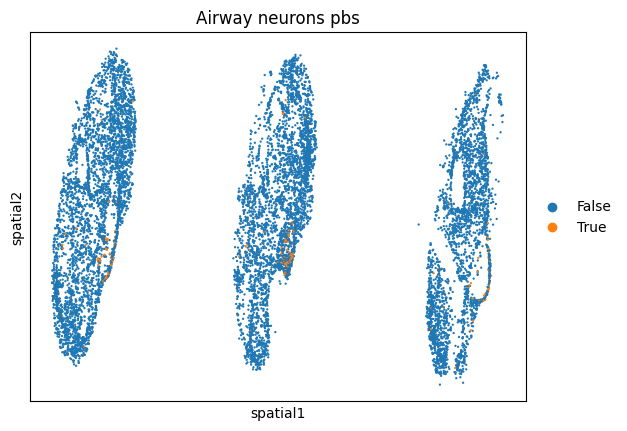

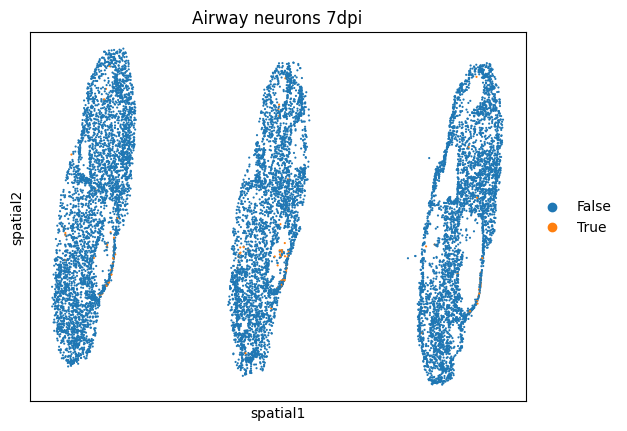

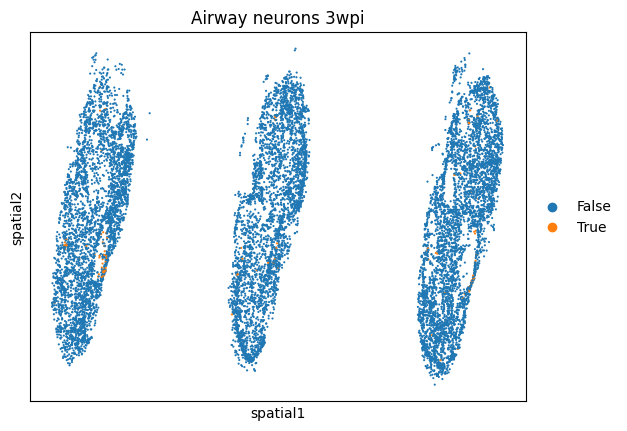

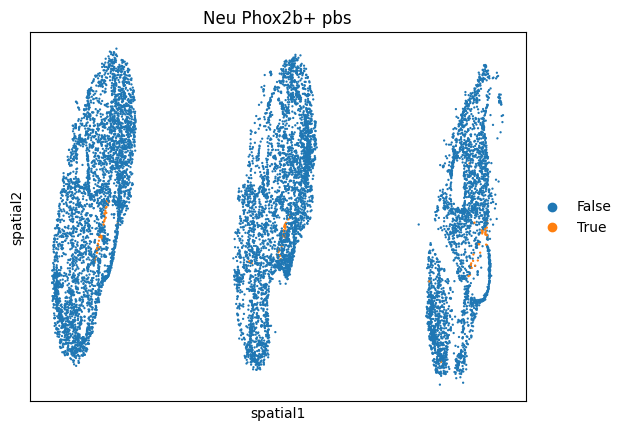

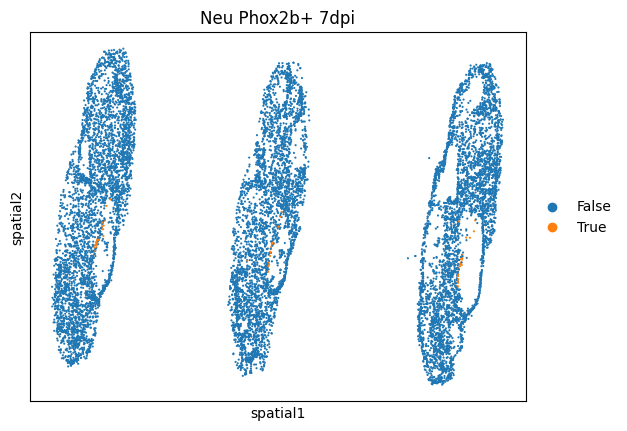

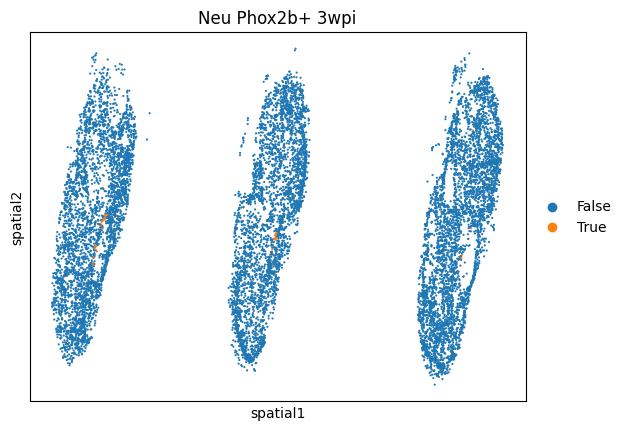

In [101]:

for ct in ["Airway neurons", "Neu Phox2b+"]:
    adata.obs["temp"] = adata.obs["celltype"] == ct
    for tp in adata.obs["timepoint"].cat.categories:
        sc.pl.embedding(adata[adata.obs["timepoint"] == tp], basis="spatial", color="temp", title=ct + " " + tp)
    adata.obs = adata.obs.drop(columns="temp")

In [ ]:
# split_adatas[adata.obs["sample"].unique()[1]].uns['celltype_co_occurrence']['interval']
tmp = adata[adata.obs["sample"] == sample].copy()
sq.gr.co_occurrence(
    tmp,
    spatial_key="SPATIAL",
    n_jobs=CORES,
    interval=np.arange(0, 2000, 100),
    cluster_key="celltype",
    show_progress_bar=False,
)
tmp.uns["celltype_co_occurrence"]['interval']
# split_adatas[sample] = tmp

array([   0.,  100.,  200.,  300.,  400.,  500.,  600.,  700.,  800.,
        900., 1000., 1100., 1200., 1300., 1400., 1500., 1600., 1700.,
       1800., 1900.], dtype=float32)

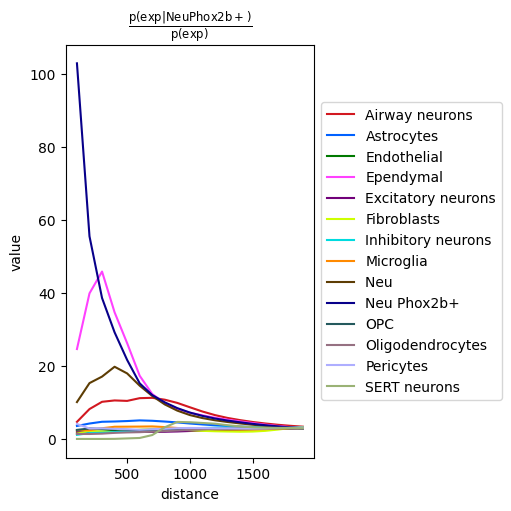

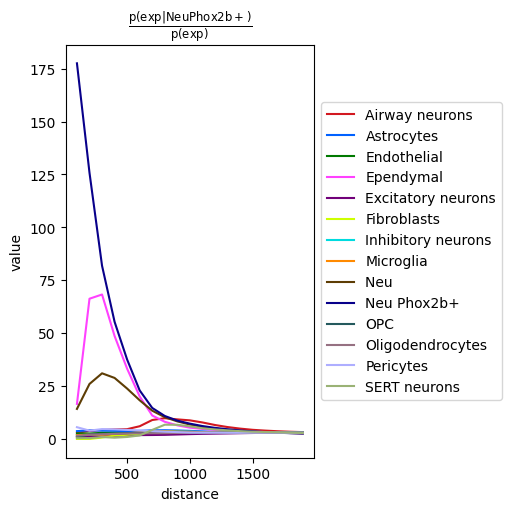

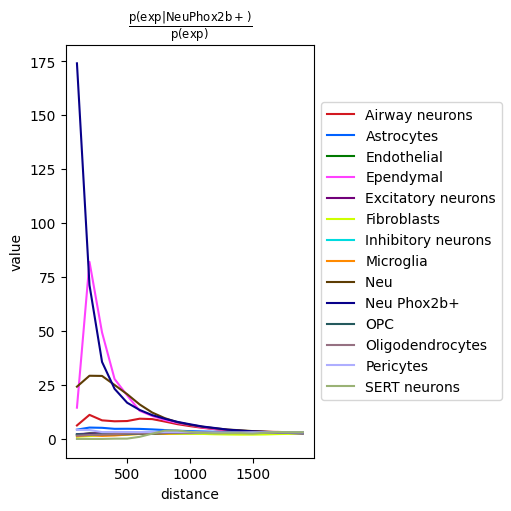

In [69]:
SAMPLES = pd.Series(split_adatas.keys())

for tp in adata.obs["timepoint"].cat.categories:
    adata.uns['celltype_co_occurrence'] = {}
    adata.uns['celltype_co_occurrence']['occ'] = np.add.reduce(
        [split_adatas[sample].uns['celltype_co_occurrence']['occ'] for sample in SAMPLES[SAMPLES.str.contains(tp)]]
    )
    adata.uns['celltype_co_occurrence']['interval'] = set_interval

    sq.pl.co_occurrence(
        adata, cluster_key="celltype", clusters="Neu Phox2b+"
    )

In [68]:
run = False
set_interval = np.arange(0, 2000, 100)
if run is True:
    warnings.filterwarnings("ignore")
    split_adatas = {}
    for sample in tqdm(adata.obs["sample"].unique()):
        tmp = adata[adata.obs["sample"] == sample].copy()
        sq.gr.co_occurrence(
            tmp,
            spatial_key="SPATIAL",
            n_jobs=CORES,
            interval=set_interval,
            cluster_key="celltype",
            show_progress_bar=False,
        )
        split_adatas[sample] = tmp

# for sample in tqdm(split_adatas):
#     sq.pl.co_occurrence(
#         split_adatas[sample], cluster_key="celltype", clusters="Neu Phox2b+"
#     )

In [ ]:
sq.pl.co_occurrence(
    split_adatas[0], cluster_key="celltype", clusters=tmp.obs["celltype"].unique()
)

# Exploratory

In [ ]:
# adata = sc.read_h5ad(DATADIR / "processed" / "external" / "neigborhoods_added.h5ad")
clear_uns(adata, "colors")

f, ax = plt.subplots(3, 1, figsize=(15, 18), layout="constrained")
sc.pl.spatial(
    adata, basis="spatial", color="batch", spot_size=100, ax=ax[0], show=False
)
sc.pl.spatial(
    adata,
    basis="spatial",
    color="timepoint",
    spot_size=100,
    ax=ax[1],
    show=False,
    palette=create_palette(3) + ["#000000"],
)
sc.pl.spatial(
    adata,
    basis="spatial",
    color="sample",
    spot_size=100,
    ax=ax[2],
    show=False,
    palette=create_palette(len(adata.obs["sample"].unique())),
)

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(15, 15), layout="constrained")
sc.pl.spatial(
    adata, basis="spatial", color="cellcharter_k8", spot_size=50, ax=ax, show=False
)
AddPailinLabels(ax, adata, 20)

f, ax = plt.subplots(1, 1, figsize=(15, 15), layout="constrained")
sc.pl.spatial(adata, basis="spatial", color="celltype", spot_size=50, ax=ax, show=False)
AddPailinLabels(ax, adata, 20)

f, ax = plt.subplots(1, 1, figsize=(15, 15), layout="constrained")
sc.pl.spatial(
    adata, basis="spatial", color="timepoint", spot_size=50, ax=ax, show=False
)
AddPailinLabels(ax, adata, 20)

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(8, 8), layout="constrained")
sc.pl.embedding(
    adata,
    basis="UMAP_SCT",
    color="celltype",
    ax=ax,
    show=False,
    legend_loc="on data",
    palette=color_gen(adata.obs["celltype"]),
)

f, ax = plt.subplots(1, 1, figsize=(8, 8), layout="constrained")
sc.pl.embedding(
    adata,
    basis="UMAP_SCT",
    color="cellcharter_k8",
    ax=ax,
    show=False,
    palette=color_gen(adata.obs["cellcharter_k8"]),
)

f, ax = plt.subplots(1, 1, figsize=(8, 8), layout="constrained")
sc.pl.embedding(
    adata,
    basis="UMAP_SCT",
    color="timepoint",
    ax=ax,
    show=False,
    palette=color_gen(adata.obs["timepoint"]),
)

In [ ]:
RUN = False

if RUN is True:
    cc.gr.enrichment(
        adata, group_key="cellcharter_k8", label_key="celltype", pvalues=True
    )
cc.pl.enrichment(
    adata,
    group_key="cellcharter_k8",
    label_key="celltype",
    figsize=(8, 4),
    group_cluster=False,
    show_pvalues=True,
    significance=0.05,
)
plt.title("Neighborhood celltype enrichment")

f = plt.figure(figsize=(12, 6), layout="constrained")
plot_cluster_barplots(adata, "timepoint", "celltype", f)
f.get_axes()[0].set_title("Neighborhood celltype composition")

if RUN is True:
    cc.gr.nhood_enrichment(adata, cluster_key="cellcharter_k8")
cc.pl.nhood_enrichment(
    adata,
    cluster_key="cellcharter_k8",
    annotate=True,
    vmin=-1,
    vmax=1,
    figsize=(5, 5),
    title="Neighborhood proximity enrichment",
)

if RUN is True:
    cc.gr.nhood_enrichment(adata, cluster_key="celltype")
cc.pl.nhood_enrichment(
    adata,
    cluster_key="celltype",
    annotate=True,
    vmin=-1,
    vmax=1,
    figsize=(8, 8),
    title="Celltype proximity enrichment",
)

In [ ]:
# cc.gr.diff_nhood_enrichment(
#     adata,
#     cluster_key='cellcharter_k8',
#     condition_key='timepoint',
#     library_key='batch',
#     pvalues=True,
#     n_jobs=20,
#     n_perms=100
# )
for tp in adata.obs["timepoint"].unique():
    if tp != "pbs":
        cc.pl.diff_nhood_enrichment(
            adata,
            cluster_key="cellcharter_k8",
            condition_key="timepoint",
            condition_groups=["pbs", tp],
            annotate=True,
            figsize=(5, 5),
            significance=0.05,
            fontsize=10,
        )

In [ ]:
# DEGs by neighborhood
deg_key = "DEGs_cck8"
cluster = "cellcharter_k8"
run = False

if run is True:
    sc.tl.rank_genes_groups(
        adata, groupby=cluster, key_added=deg_key, layer="normalized"
    )

sc.pl.rank_genes_groups(adata, groupby=cluster, key=deg_key)
sc.pl.rank_genes_groups_dotplot(
    adata,
    groupby=cluster,
    key=deg_key,
    n_genes=10,
    standard_scale="var",
    layer="normalized",
)

In [ ]:
# Fos by grouping

f, ax = plt.subplots(1, 1, figsize=(18, 5), layout="constrained")
sc.pl.spatial(
    adata,
    basis="spatial",
    color="Fos",
    spot_size=100,
    frameon=False,
    layer="normalized",
    cmap="Blues",
    ax=ax,
)

f, ax = plt.subplots(1, 1, figsize=(10, 10), layout="constrained")
sc.pl.embedding(
    adata,
    basis="UMAP_SCT",
    color="Fos",
    frameon=False,
    layer="normalized",
    cmap="Blues",
    ax=ax,
)

sc.pl.dotplot(
    adata,
    var_names="Fos",
    groupby=["timepoint"],
    swap_axes=True,
    title="Fos expression by timepoint",
    layer="normalized",
)
sc.pl.dotplot(
    adata,
    var_names="Fos",
    groupby=["cellcharter_k8"],
    swap_axes=True,
    title="Fos expression by neighborhood",
    layer="normalized",
)
sc.pl.dotplot(
    adata,
    var_names="Fos",
    groupby=["celltype"],
    swap_axes=True,
    title="Fos expression by celltype",
    layer="normalized",
)

sc.pl.dotplot(
    adata,
    var_names="Fos",
    groupby=["celltype.timepoint"],
    swap_axes=True,
    title="Fos expression by celltype over time",
    layer="normalized",
)

sc.pl.dotplot(
    adata,
    var_names="Fos",
    groupby=["neighborhood.timepoint"],
    swap_axes=True,
    title="Fos expression by neighborhood over time",
    layer="normalized",
)

# Requested Plots 12/10
- change cell definitions to original ones

how are other cells interacting with Fos+ NTS neuron
- DEGs by timepoint, per celltype (e.g. like Fos+ only)
- colocalization of cells + celltype communication + neighborhood coenrichment
- focus on 6 & 7

### Object Updates

In [ ]:
adata = sc.read_h5ad(DATADIR / "processed" / "external" / "neigborhoods_added.h5ad")
adata.layers["normalized"] = adata.layers["logcounts"].copy()
del adata.layers["logcounts"]

adata.obs["sample"] = adata.obs["sample"].astype("category")
order_obs(adata, "timepoint", order=["pbs", "7dpi", "3wpi"])
clear_uns(adata, "colors")

celltype_mapping = {
    0: "Inhibitory neurons",
    1: "Excitatory neurons",
    2: "Astrocytes",
    3: "Oligodendrocytes",
    4: "Endothelial",
    5: "Oligodendrocytes",
    6: "Excitatory neurons",
    7: "Excitatory neurons",
    8: "Microglia",
    9: "Pericytes",
    10: "OPC",
    11: "Fibroblasts",
    12: "Airway neurons",
    13: "Astrocytes",
    14: "Neu ",
    15: "Neu Phox2b+",
    16: "Oligodendrocytes",
    17: "SERT neurons",
    18: "Ependymal",
}
adata.obs["celltype"] = (
    adata.obs["seurat_clusters"].astype(int).map(celltype_mapping).astype("category")
)

adata.obs["celltype.timepoint"] = (
    adata.obs["celltype"].astype(str) + "_" + adata.obs["timepoint"].astype(str)
)
adata.obs["celltype.timepoint"] = adata.obs["celltype.timepoint"].astype("category")

adata.obs["neighborhood.timepoint"] = (
    adata.obs["cellcharter_k8"].astype(str) + "_" + adata.obs["timepoint"].astype(str)
)
adata.obs["neighborhood.timepoint"] = adata.obs["neighborhood.timepoint"].astype(
    "category"
)

adata

In [ ]:
# Add SCT Information

R_preload()
with ro.conversion.localconverter(converter):
    ro.r("""
    Seurat_obj <- readRDS(file = '../../../data/processed/external/CU048_ConfPositioned_seurat_spatial_merged.rds')
    DefaultAssay(Seurat_obj) <- 'SCT'
    sce_SCT <- as.SingleCellExperiment(Seurat_obj)
    pca_embed <- Embeddings(Seurat_obj, reduction = "pca")
    umap_embed <- Embeddings(Seurat_obj, reduction = "umap")
    """)
    adata_SCT = ro.globalenv["sce_SCT"]
    adata_SCT.obsm["PCA_SCT"] = ro.globalenv["pca_embed"]
    adata_SCT.obsm["UMAP_SCT"] = ro.globalenv["umap_embed"]

adata_SCT = adata_SCT[adata.obs_names]

adata.obsm["SCT_raw"] = adata_SCT.X.copy()
adata.obsm["SCT_log"] = adata_SCT.layers["logcounts"].copy()
adata.obsm["PCA_SCT"] = adata_SCT.obsm["PCA_SCT"].copy()
adata.obsm["UMAP_SCT"] = adata_SCT.obsm["UMAP_SCT"].copy()

### DEGs

In [ ]:
compare = "timepoint"
cluster = "cellcharter_k8"
key = f"{compare}_DEGs"

for group in adata.obs[cluster].cat.categories:
    subset = adata[adata.obs[cluster] == group]

    sc.tl.rank_genes_groups(
        subset, groupby=compare, method="wilcoxon", layer="normalized", key_added=key
    )

    # sc.pl.rank_genes_groups(subset, key=key)
    sc.pl.rank_genes_groups_dotplot(
        subset,
        groupby=compare,
        n_genes=10,
        layer="normalized",
        title=f"neigborhood {group} by timepoint",
        dendrogram=False,
        key=key,
    )

    # sc.pl.rank_genes_groups_heatmap(
    #     subset,
    #     groupby=compare,
    #     layer="normalized",
    #     dendrogram=False,
    #     cmap="Blues",
    #     key=key,
    # )

    adata.uns[f"neighborhood {group}_{key}"] = subset.uns[key].copy()

In [ ]:
compare = "timepoint"
cluster = "celltype"
key = f"{compare}_DEGs"

for group in adata.obs[cluster].cat.categories:
    subset = adata[adata.obs[cluster] == group]

    sc.tl.rank_genes_groups(
        subset, groupby=compare, method="wilcoxon", layer="normalized", key_added=key
    )

    # sc.pl.rank_genes_groups(subset, key=key)
    sc.pl.rank_genes_groups_dotplot(
        subset,
        groupby=compare,
        n_genes=10,
        layer="normalized",
        title=f"{group} by timepoint",
        dendrogram=False,
        key=key,
    )

    adata.uns[f"{group}_{key}"] = subset.uns[key].copy()

# Requested Plots 1/13

IFN Module Scores

In [ ]:
genesets = {}

rmj_genelist = pd.read_csv(REFDIR / "RMJ_MERFISH.csv").iloc[:, 1].values
genesets["RMJ"] = [gene for gene in rmj_genelist if gene in adata.var_names]

hobson_genelist = pd.read_csv(REFDIR / "Hobson BBI 2023 Bulk RNAseq DEGs.csv")
hobson_genelist = hobson_genelist[
    hobson_genelist["Contrast"] == "NeuPos_IFN-v-Sal_48h"
].sort_values("padj")
genesets["Hobson"] = hobson_genelist[hobson_genelist["padj"] < 0.05]["gene_name"].values

In [ ]:
adata.X = adata.layers["normalized"].copy()

for normalize in [True, False]:
    module_score(adata, genesets, "Seurat", zscore=normalize)
    module_score(adata, genesets, "UCell", zscore=normalize)
    module_score(adata, genesets, "AUCell", zscore=normalize)

    subset = adata[
        adata.obs["celltype"].isin(
            ["Endothelial", "Airway neurons", "Oligodendrocytes", "Microglia"]
        )
    ]
    score_cols = [
        col for col in subset.obs.columns if ("RMJ" in col or "Hobson" in col)
    ]
    for group in ["celltype.timepoint"]:
        # sc.pl.matrixplot(
        #     subset, var_names=score_cols, groupby=group, cmap="RdBu", vmin=-2, vmax=2, swap_axes=True,
        # )
        means = [(n, df[score_cols].mean()) for n, df in subset.obs.groupby(group)]
        df = pd.concat([i[1] for i in means], axis=1, keys=[i[0] for i in means]).T
        df[:] = scipy.stats.zscore(df)
        plt.figure()
        sns.heatmap(df.T, cmap="RdBu_r", square=True)

        # f = plt.figure(figsize=(12, 9))
        # plot_violinplot(subset, f=f, group=group, markers=score_cols, y_fontsize=9)
        # axs = f.get_axes()
        # for ax in axs:
        #     ax.axhline(0, color="black")

    gc.collect()

0it [00:00, ?it/s]
/tmp/ipykernel_129568/914382561.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


deleted from `obs`:  Index([], dtype='object')


8729

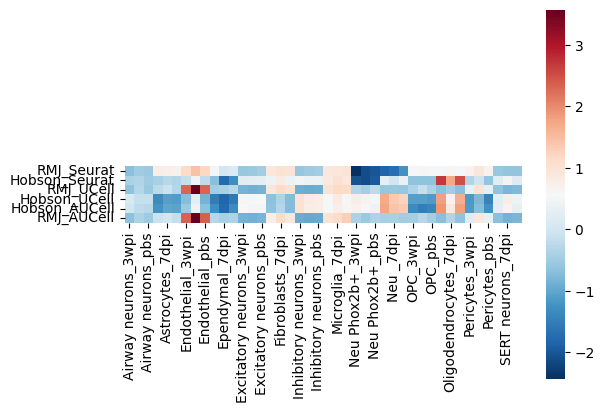

In [ ]:
genesets = {}
normalize = False

adata.X = adata.layers["normalized"].copy()

module_score(adata, genesets, "UCell", zscore=normalize)

score_cols = [
    col for col in adata.obs.columns if ("RMJ" in col or "Hobson" in col)
]

gc.collect()

/tmp/ipykernel_129568/303723868.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


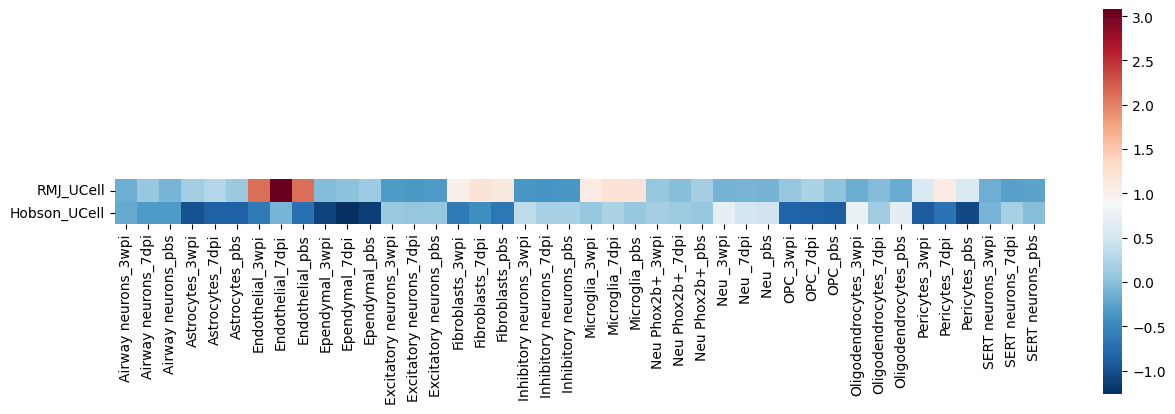

In [10]:
score_cols = [
    col for col in adata.obs.columns if ("_UCell" in col)
]
for group in ["celltype.timepoint"]:
    # sc.pl.matrixplot(
    #     subset, var_names=score_cols, groupby=group, cmap="RdBu", vmin=-2, vmax=2, swap_axes=True,
    # )
    means = [(n, df[score_cols].mean()) for n, df in adata.obs.groupby(group)]
    df = pd.concat([i[1] for i in means], axis=1, keys=[i[0] for i in means]).T
    # df[:] = scipy.stats.zscore(df)
    plt.figure(figsize=(15,5))
    sns.heatmap(df.T, cmap="RdBu_r", square=True)

Plotting violins (None):   0%|          | 0/2 [00:00<?, ?it/s]/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:965: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:965: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
Plotting violins (None):  50%|█████     | 1/2 [00:01<00:01,  1.86s/it]/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:965: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/

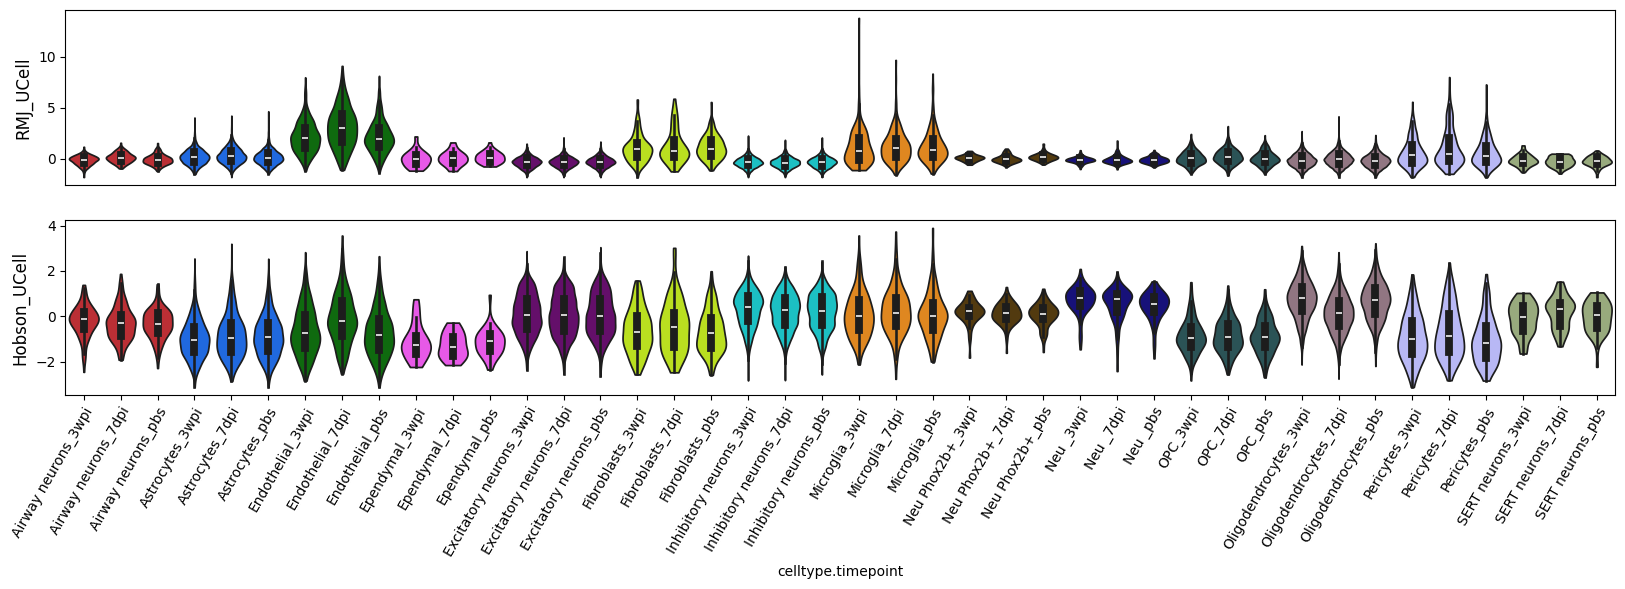

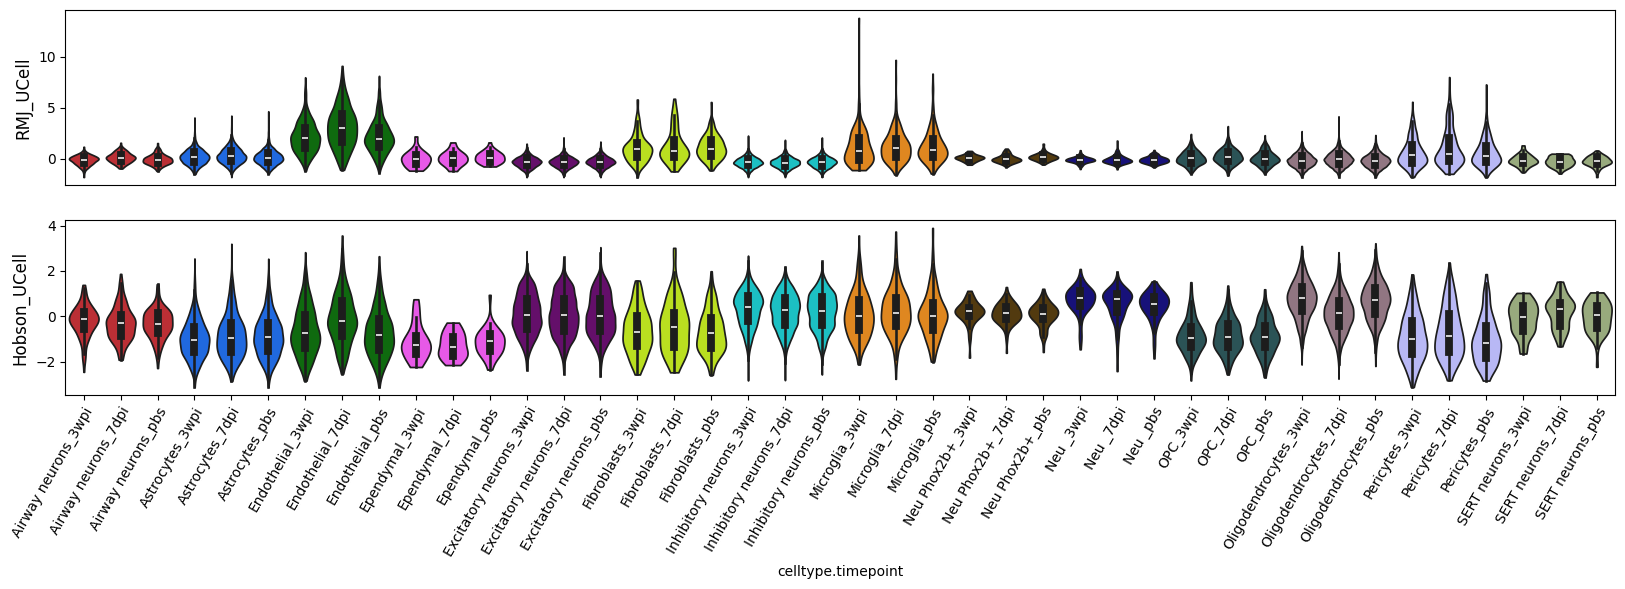

In [11]:
plot_violinplot(adata, "celltype.timepoint", score_cols, inner="box",
                palette=np.repeat(adata.uns['celltype_colors'], 3),
                f=plt.figure(figsize=(20,5)))

Fos expression by celltype / timepoints

In [ ]:
subset = adata[adata.obs["celltype"].str.contains("neu", case=False)]

f, ax = plt.subplots(1, 1, figsize=(15, 2.5))
dp = sc.pl.dotplot(
    subset,
    var_names="Fos",
    groupby=["neighborhood.timepoint"],
    swap_axes=True,
    title="Fos expression by neighborhood over time, neurons ONLY",
    layer="normalized",
    smallest_dot=1,
    ax=ax,
    # figsize=(8,2)
)
# dp.add_totals().style(dot_edge_color='black', dot_edge_lw=0.5).show()

sc.pl.matrixplot(
    subset,
    var_names="Fos",
    groupby=["neighborhood.timepoint"],
    swap_axes=True,
    title="Fos expression by neighborhood over time, neurons ONLY",
    layer="normalized",
    cmap="Reds",
)

In [ ]:
# zoom in on neighborhood 7
subset2 = subset[subset.obs["cellcharter_k8"] == "7"]
sc.pl.DotPlot.DEFAULT_SIZE_EXPONENT = 2
sc.pl.dotplot(
    subset2,
    var_names="Fos",
    groupby=["timepoint"],
    swap_axes=True,
    title="Fos expression in neighborhood 7, neurons ONLY",
    layer="normalized",
    return_fig=True,
    dot_min=0.01,
    figsize=(8, 3),
).style(largest_dot=1000, smallest_dot=1, dot_edge_lw=0.5).legend(width=2.5).show()

# Sandbox

/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/anndata/_core/anndata.py:1208: I

Text(0.5, 0.98, 'Neu  - Neu Phox2b+ pairs within 187.5 pixel range')

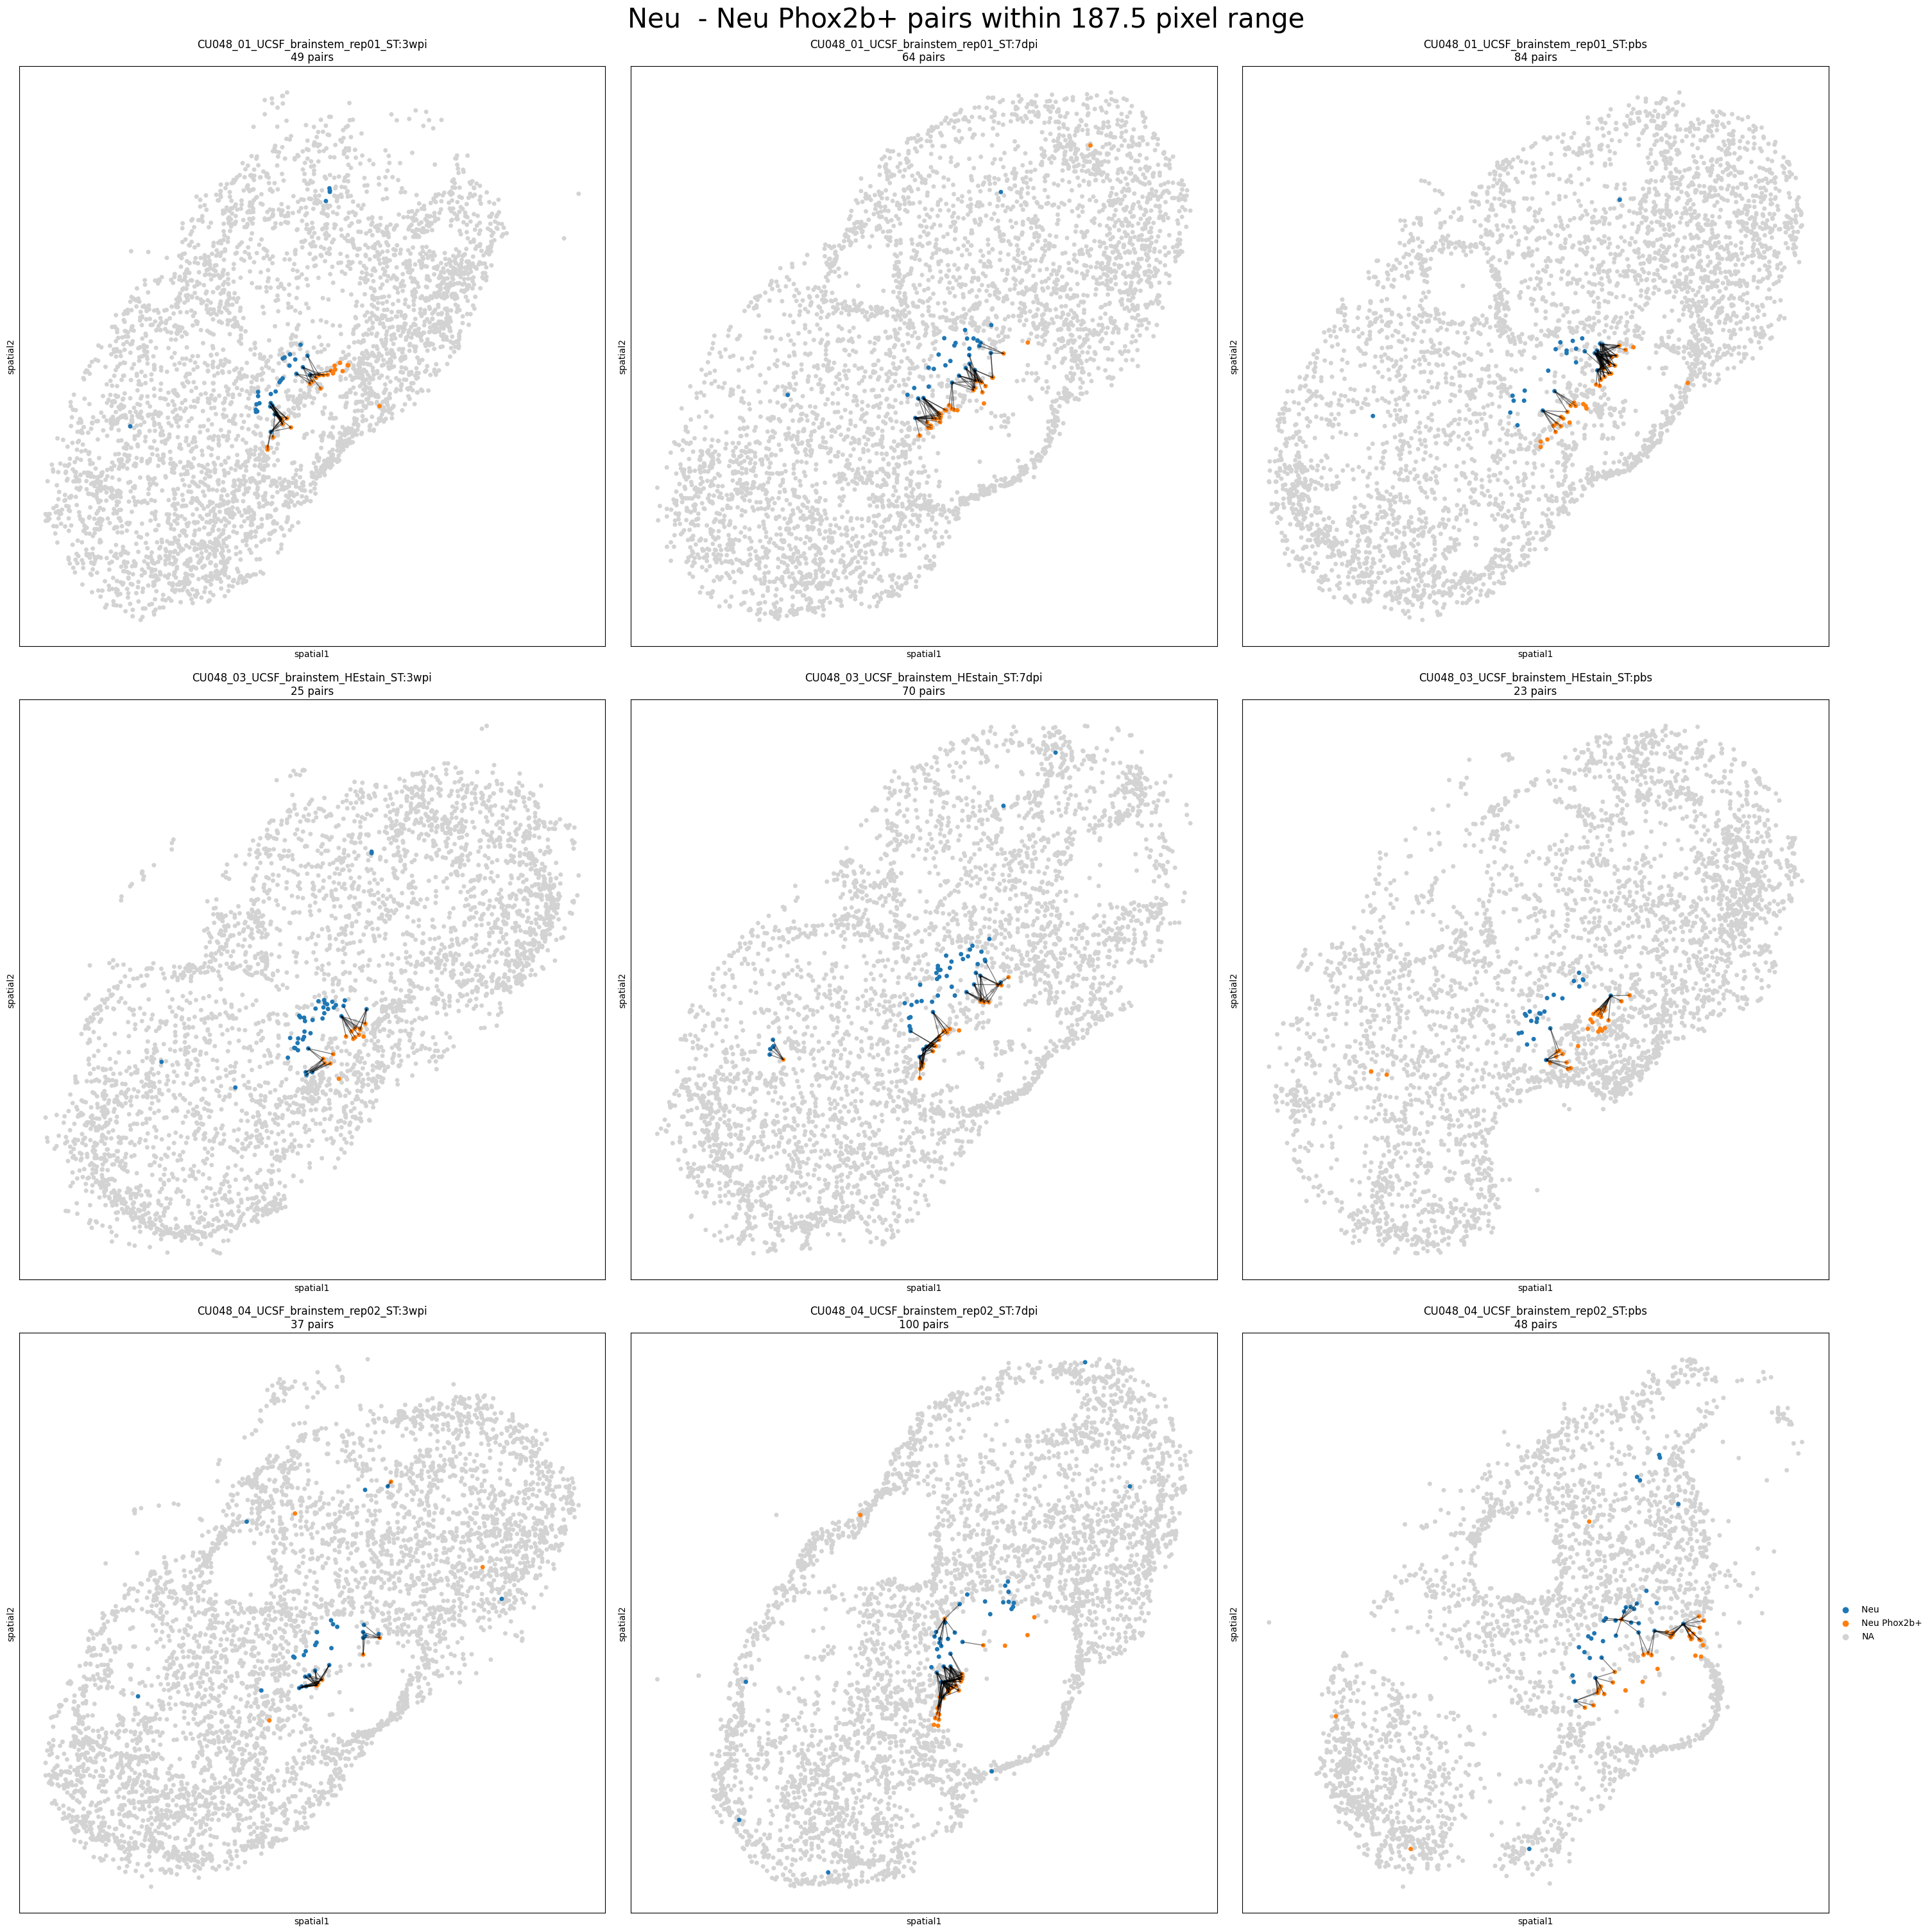

In [3]:
def plot_cross_type_neighbors(
    adata,
    celltype_key,
    ct1,
    ct2,
    radius,
    title=None,
    ax=None,
    pointsize=None,
    basis="spatial",
    spatial_key="spatial",
    max_pairs_per_cell=None,
    line_color="black",
    line_alpha=0.5,
    line_width=1,
):
    """
    Plot spatial embedding with original cell colors preserved, and draw lines
    between cross-type neighbors only (ct1 <-> ct2) within `radius`.

    Parameters
    ----------
    adata : AnnData
    celltype_key : str
        Column in adata.obs containing cell type labels.
    ct1, ct2 : str
        The two cell types to connect.
    radius : float
        Maximum Euclidean distance for a pair to count as neighbors.
    basis : str
        Embedding basis for scanpy plotting (default: "spatial").
    spatial_key : str
        Key in adata.obsm containing coordinates (default: "spatial").
    max_pairs_per_cell : int or None
        If set, keep only the closest N partners from ct2 for each ct1 cell.
        Set to None to draw all pairs within radius.
    line_color, line_alpha, line_width :
        Styling for the connecting lines.

    Returns
    -------
    pairs : list[tuple[int, int]]
        List of paired cell indices (adata indices).
    """
    if ax is None:
        ax = plt.subplots(1,1,figsize=(10,10))[1]

    xy = np.asarray(adata.obsm[spatial_key])
    ct = adata.obs[celltype_key].astype(str).to_numpy()

    idx1 = np.where(ct == ct1)[0]
    idx2 = np.where(ct == ct2)[0]

    if len(idx1) == 0:
        raise ValueError(f"No cells found for ct1='{ct1}' in adata.obs[{celltype_key!r}].")
    if len(idx2) == 0:
        raise ValueError(f"No cells found for ct2='{ct2}' in adata.obs[{celltype_key!r}].")

    p1 = xy[idx1]
    p2 = xy[idx2]

    # Pairwise squared distances between ct1 and ct2 only
    d2 = ((p1[:, None, :] - p2[None, :, :]) ** 2).sum(axis=2)
    within = d2 <= radius**2

    pairs = []
    for i in range(len(idx1)):
        js = np.where(within[i])[0]
        if len(js) == 0:
            continue

        if max_pairs_per_cell is not None:
            js = js[np.argsort(d2[i, js])[:max_pairs_per_cell]]

        for j in js:
            pairs.append((idx1[i], idx2[j]))
    
    if title is not None:
        title += f"\n{len(pairs)} pairs"

    # Base plot with original colors preserved
    
    sc.pl.embedding(adata, basis=basis, color=celltype_key, ax=ax, show=False, size=pointsize, title=title)

    # Overlay only the connecting lines
    for a, b in pairs:
        ax.plot(
            [xy[a, 0], xy[b, 0]],
            [xy[a, 1], xy[b, 1]],
            color=line_color,
            alpha=line_alpha,
            linewidth=line_width,
            zorder=1,
        )

    return pairs


ct1, ct2 = "Neu ", "Neu Phox2b+"
r = 250 * 0.75

adata.obs['temp'] = adata.obs['celltype'].apply(
    lambda x: x if x in [ct1, ct2] else np.nan
)

f, axs = plt.subplots(3,3, figsize=(30,30), layout="constrained")
axs = axs.flatten()

for i in range(9):
    sample_name = adata.obs["sample"].cat.categories[i]
    samp = adata[adata.obs["sample"] == sample_name]
    pairs = plot_cross_type_neighbors(
        samp,
        celltype_key="temp",
        ct1=ct1,
        ct2=ct2,
        radius=r,
        ax=axs[i],
        title=sample_name,
        pointsize=100,
    )
    if i != 8:
        axs[i].get_legend().remove()

f.suptitle(f"{ct1} - {ct2} pairs within {r} pixel range", size=30)

Plotting violins (None):   0%|          | 0/1 [00:00<?, ?it/s]

Plotting violins (None): 100%|██████████| 1/1 [00:01<00:00,  1.22s/it]
/mnt/DATA/home/ethung/projects/spatial_seq/src/notebooks/pailin/../../single_cell/plot.py:369: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


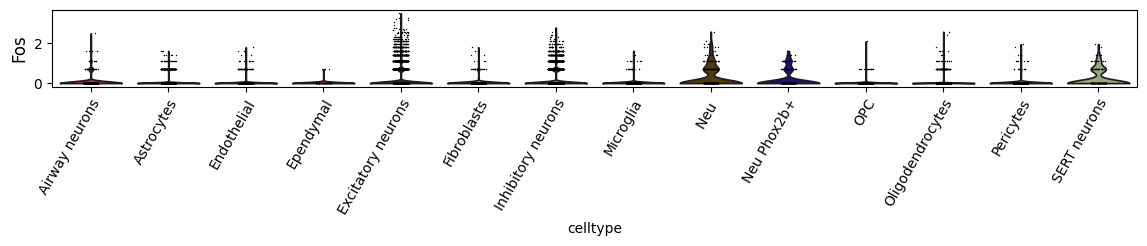

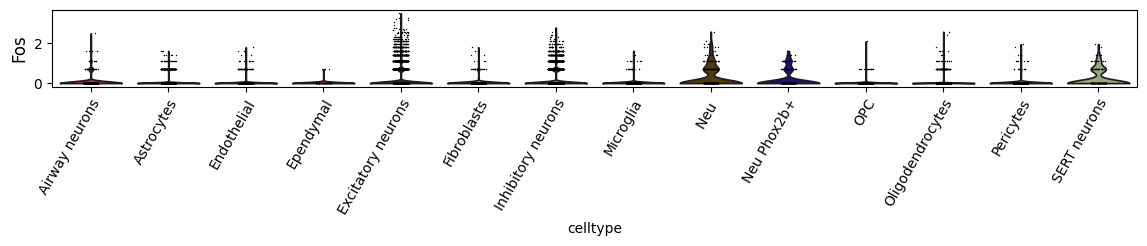

In [10]:
plot_violinplot(adata, "celltype", ["Fos"], useStripPlot=True, inner=None)

In [ ]:
neurons_only = adata[adata.obs["celltype"].str.contains("neu", case=False)]
neurons_only.obs["has_Fos"] = neurons_only[:,"Fos"].X.toarray() > 0
neurons_only.obs["has_Fos"] = neurons_only.obs["has_Fos"].astype(str)

/tmp/ipykernel_151603/606837160.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


In [101]:
pd.crosstab(neurons_only.obs["celltype"], neurons_only.obs["timepoint"]).to_csv('neuron counts.csv')

In [97]:
temp = neurons_only[neurons_only.obs["celltype"].isin(["Airway neurons", "Neu ", "Neu Phox2b+"])]
pd.crosstab(temp.obs["sample"], temp.obs["has_Fos"])

has_Fos,False,True
sample,,
CU048_01_UCSF_brainstem_rep01_ST:3wpi,105,16
CU048_01_UCSF_brainstem_rep01_ST:7dpi,90,19
CU048_01_UCSF_brainstem_rep01_ST:pbs,113,25
CU048_03_UCSF_brainstem_HEstain_ST:3wpi,53,21
CU048_03_UCSF_brainstem_HEstain_ST:7dpi,105,26
CU048_03_UCSF_brainstem_HEstain_ST:pbs,131,24
CU048_04_UCSF_brainstem_rep02_ST:3wpi,83,13
CU048_04_UCSF_brainstem_rep02_ST:7dpi,78,22
CU048_04_UCSF_brainstem_rep02_ST:pbs,107,31


                                               psbulk_cells  psbulk_counts
CU048_04_UCSF_brainstem_rep02_ST:3wpi_True             13.0       141038.0
CU048_01_UCSF_brainstem_rep01_ST:3wpi_True             16.0       366510.0
CU048_01_UCSF_brainstem_rep01_ST:7dpi_True             19.0       511240.0
CU048_03_UCSF_brainstem_HEstain_ST:3wpi_True           21.0       576977.0
CU048_04_UCSF_brainstem_rep02_ST:7dpi_True             22.0       462704.0
CU048_03_UCSF_brainstem_HEstain_ST:pbs_True            24.0       338271.0
CU048_01_UCSF_brainstem_rep01_ST:pbs_True              25.0       617697.0
CU048_03_UCSF_brainstem_HEstain_ST:7dpi_True           26.0       881720.0
CU048_04_UCSF_brainstem_rep02_ST:pbs_True              31.0       669223.0
CU048_03_UCSF_brainstem_HEstain_ST:3wpi_False          53.0       719258.0
CU048_04_UCSF_brainstem_rep02_ST:7dpi_False            78.0       887926.0
CU048_04_UCSF_brainstem_rep02_ST:3wpi_False            83.0       792125.0
CU048_01_UCSF_brainstem_r

  0%|          | 0/3 [00:00<?, ?it/s]/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/pydeseq2/dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/pydeseq2/utils.py:1088: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))
/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/pydeseq2/utils.py:1088: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))
/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/pydeseq2/utils.py:1088: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))
/mnt/DATA/home/et

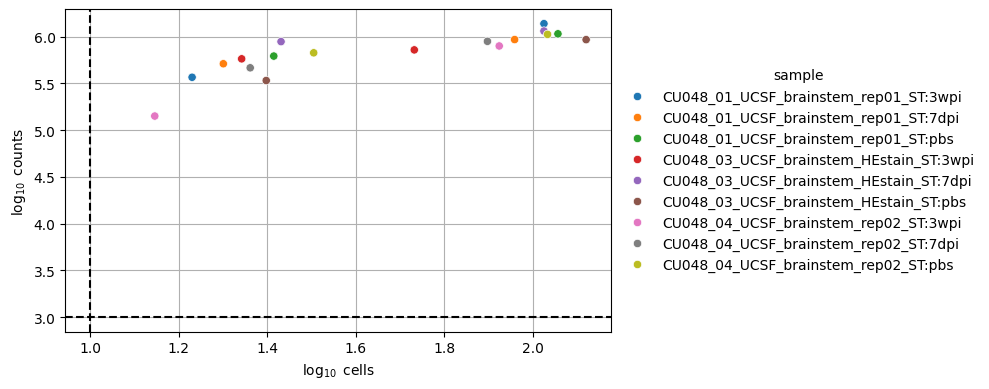

In [98]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

condition_key = "has_Fos"
covariates = ["batch", "timepoint"]
comparison = [condition_key, 'True', 'False']
pbulk_DEG_results = {}
quiet = True

# Pseudobulk DEGs
pdata = dc.pp.pseudobulk(
    temp,
    sample_col="sample",
    groups_col="has_Fos",
    layer='counts',
    mode='sum'
)

print(pdata.obs[["psbulk_cells", "psbulk_counts"]].sort_values("psbulk_cells"))

# filter samples based on number of cells and counts
dc.pp.filter_samples(pdata, min_cells = 10, min_counts=1000)

for col in ['sample']:
    dc.pl.filter_samples(pdata, groupby=col, figsize=(10, 4))

for tp in tqdm(pdata.obs["timepoint"].unique()):
    tpdata = pdata[pdata.obs["timepoint"] == tp].copy()

    # Obtain genes that pass the edgeR-like thresholds
    # NOTE: QC thresholds might differ between cell types, consider applying them by cell type
    genes = dc.pp.filter_by_expr(
        tpdata,
        group=condition_key,
        min_count=10, # a minimum number of counts in a number of samples
        min_total_count=20, # a minimum total number of reads across samples
        inplace=False)

    # Filter by these genes
    tpdata = tpdata[:, genes].copy()
    
    # Build DESeq2 object
    # NOTE: this data is actually paired, so one could consider fitting the patient label as a confounder
    dds = DeseqDataSet(
        adata=tpdata,
        design=f'~{condition_key}+{covariates[0]}+{covariates[1]}',
        refit_cooks=True,
        quiet=quiet,
        n_cpus = 10
    )
    
    # Compute LFCs
    dds.deseq2()
    stat_res = DeseqStats(dds, contrast=comparison, quiet=quiet)
    stat_res.summary() # Compute Wald test
    # Shrink LFCs
    stat_res.lfc_shrink(coeff=tpdata.varm['LFC'].columns[1]) # {condition_key}_cond_vs_ref
    
    pbulk_DEG_results[tp] = stat_res.results_df

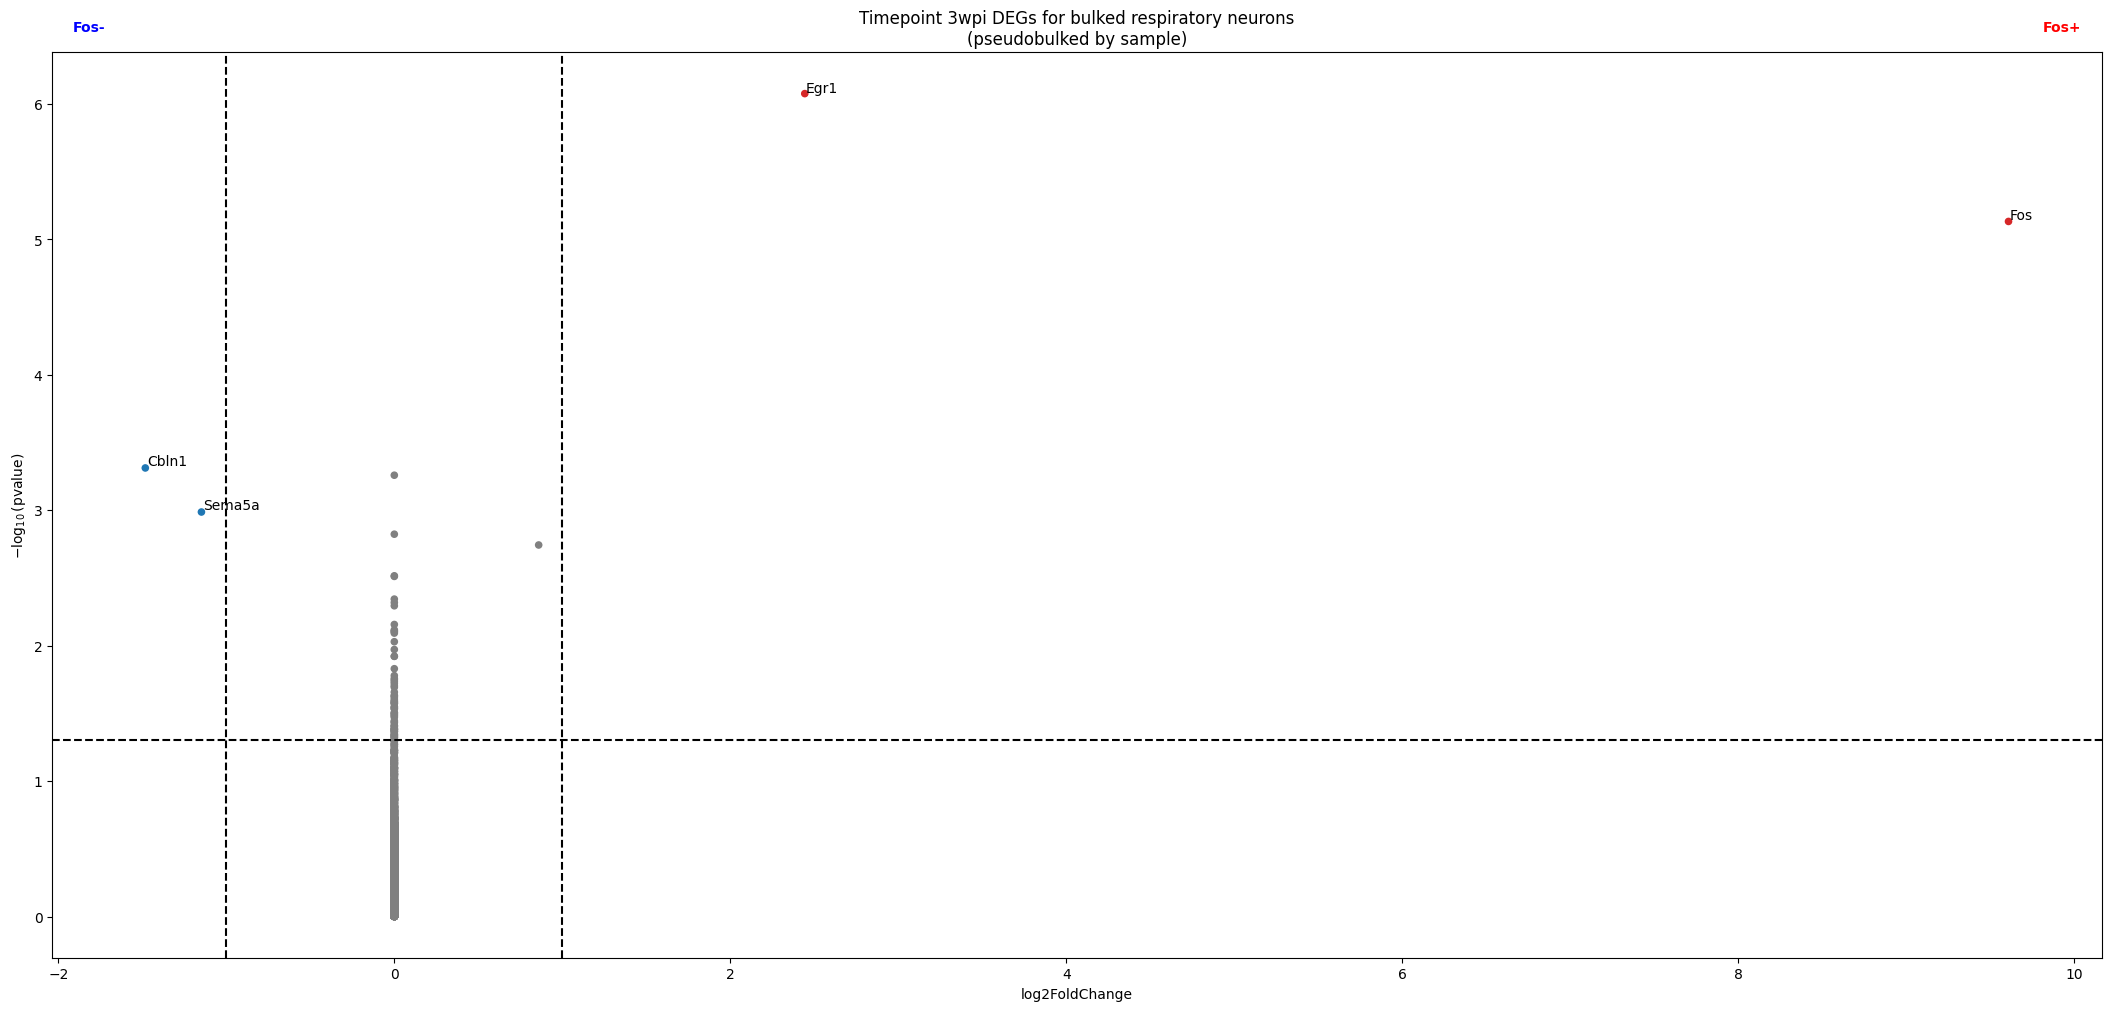

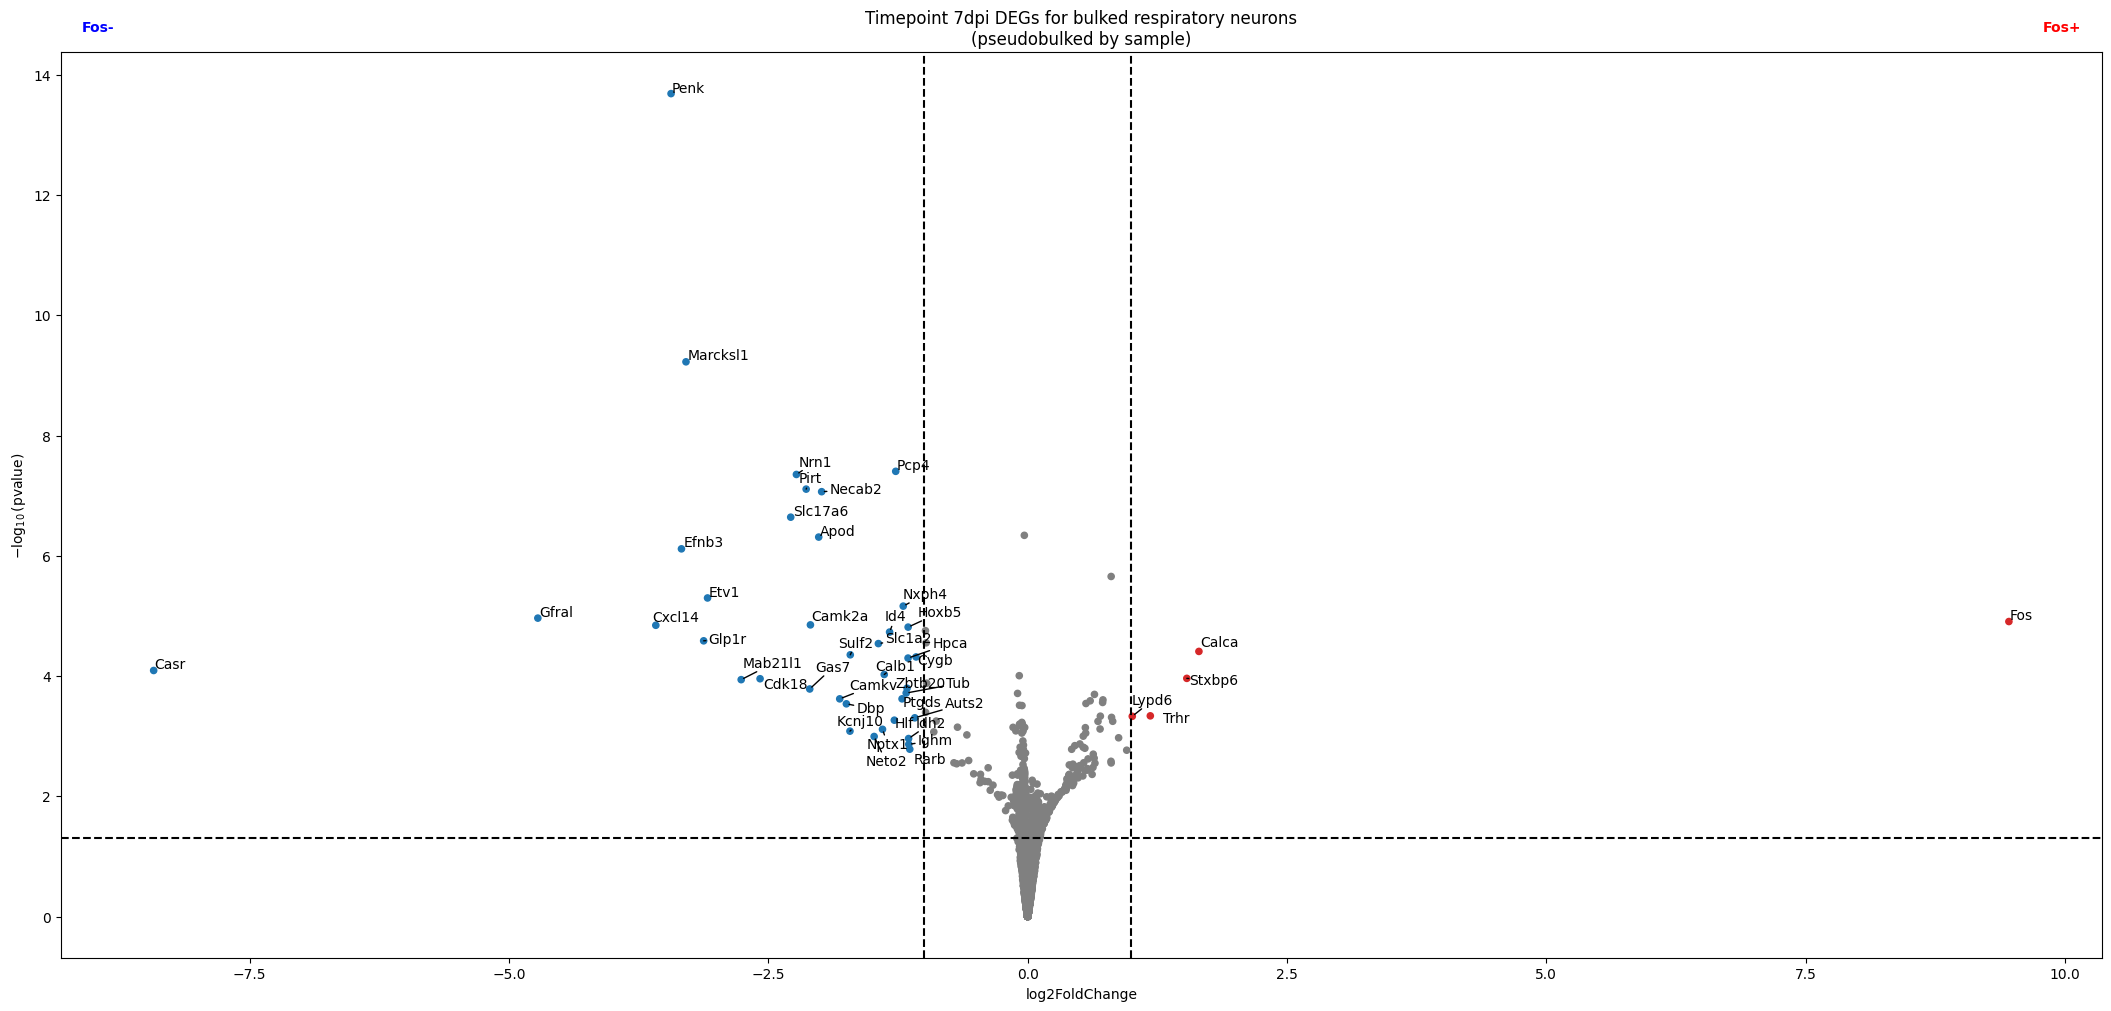

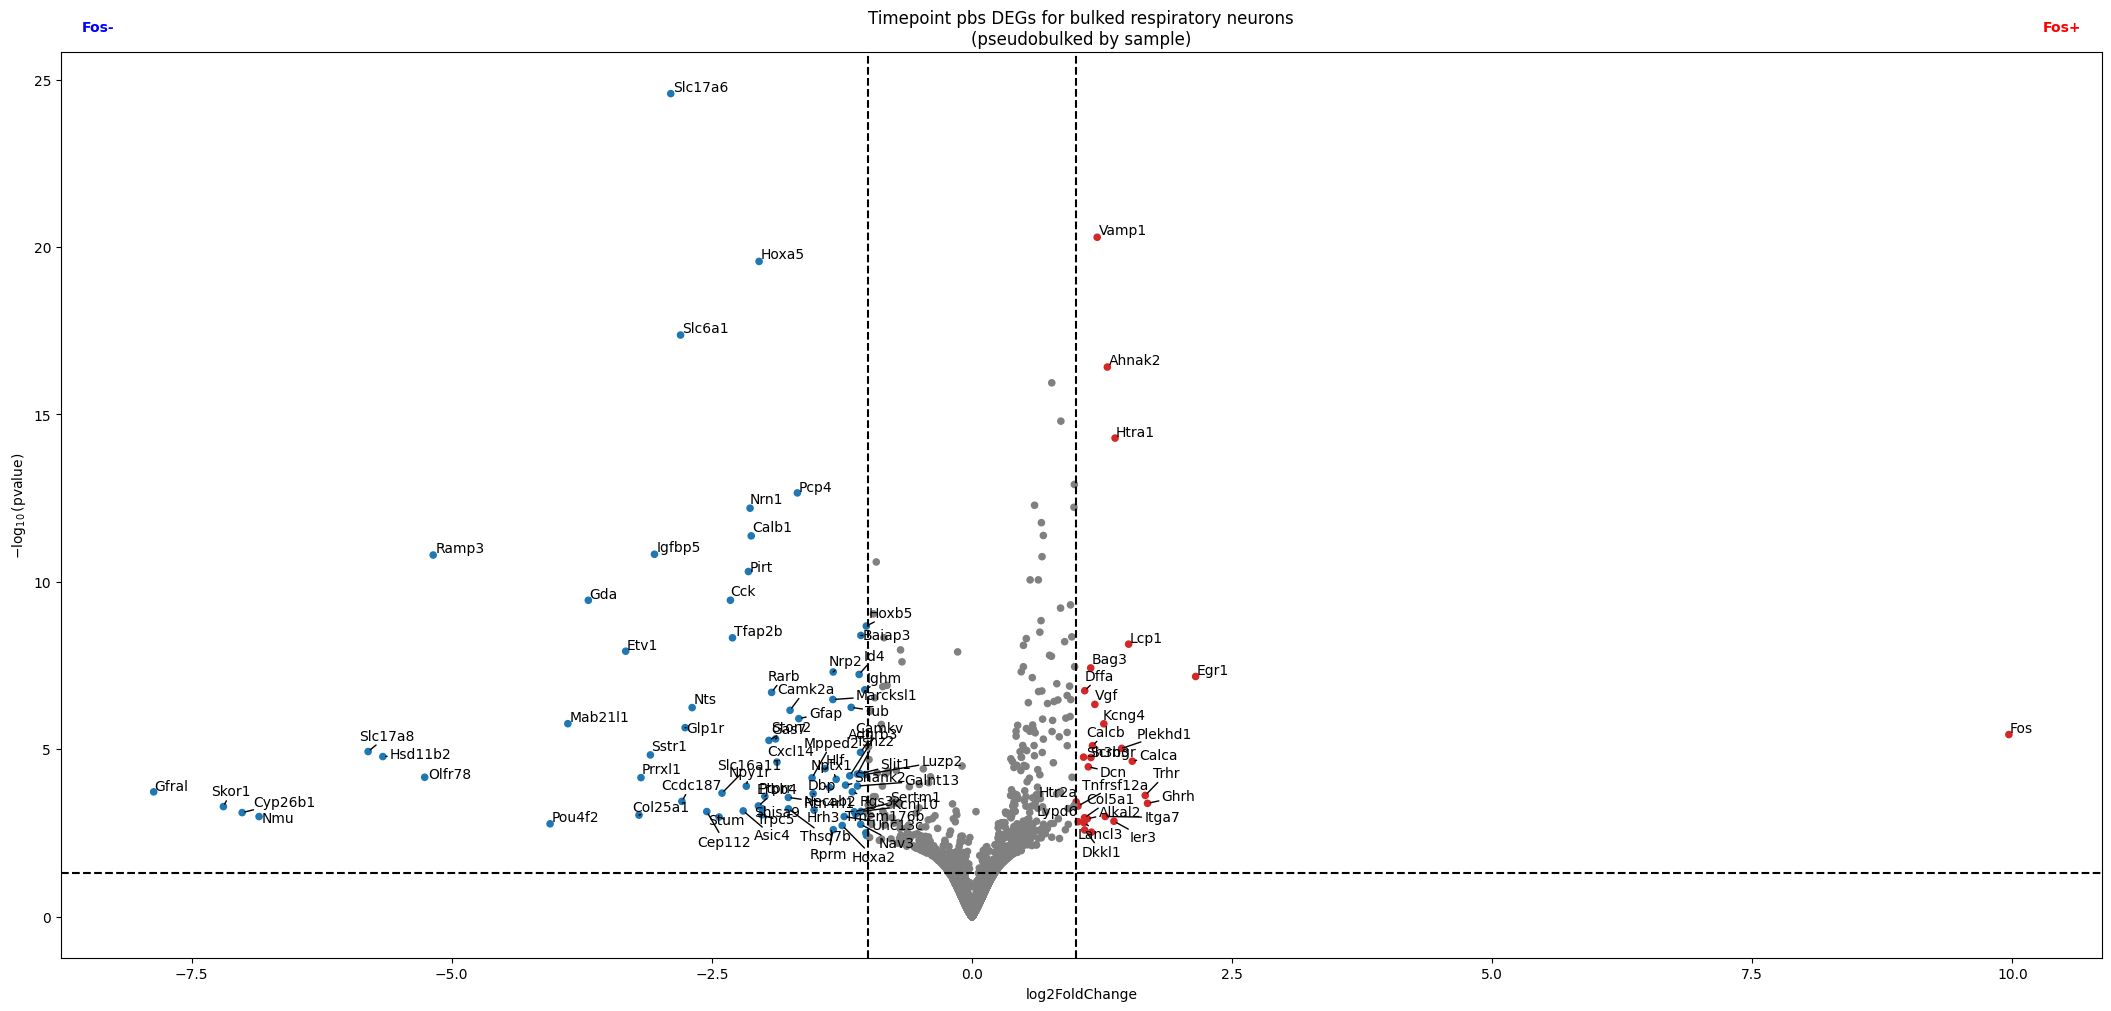

In [99]:
for ct in pbulk_DEG_results:
    ax = plt.subplots(1,1, figsize=(21,10), layout="constrained")[1]
    dc.pl.volcano(pbulk_DEG_results[ct], x="log2FoldChange", y="pvalue", ax=ax,
                  thr_stat=1, top=100)

    ax.text(
        0.01, 1.02, "Fos-",
        transform=ax.transAxes,
        ha="left", va="bottom",
        color="blue", fontweight="bold"
    )
    ax.text(
        0.99, 1.02, "Fos+",
        transform=ax.transAxes,
        ha="right", va="bottom",
        color="red", fontweight="bold"
    )
    ax.set_title(f"Timepoint {ct} DEGs for bulked respiratory neurons\n(pseudobulked by sample)")


# Save/Load

In [ ]:
adata.write_zarr(DATADIR / "analyzed.zarr")
adata.write(DATADIR / "analyzed.h5ad")

In [ ]:
del adata.uns
adata.write(DATADIR / "analyzed_SLIM.h5ad")

In [2]:
adata = ad.read_zarr(DATADIR / "analyzed.zarr")
adata

AnnData object with n_obs × n_vars = 36344 × 19059
    obs: 'batch', 'nCount_RNA', 'nFeature_RNA', 'number_clusters', 'percent.mt', 'log10_nCount_RNA', 'log10_nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.2', 'seurat_clusters', 'x', 'y', 'celltype', 'timepoint', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'sample', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.30', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.40', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.50', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.60', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.70', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.80', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.90', 'BANKSY_labels_nonspatial_pc30_nc0.00_r1.00', 'BANKSY_labels_scaled_gaussian_pc30_nc0.20_r0.30', 'BANKSY_labels_scaled_ga